<a href="https://colab.research.google.com/github/goldedan7/robot-dynamics/blob/main/P3_dynamics/P3_RobotArm_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
np.set_printoptions(precision=3, suppress=True)

print("✓ Libraries ready")

✓ Libraries ready


In [105]:
# Link lengths (m)
L1 = 1.0
L2 = 0.8

# Link masses (kg) -- assume mass is concentrated at the end of each link (point-mass model)
m1 = 1.0
m2 = 0.8

g = 9.81   # gravity (m/s^2)

print(f"Link 1: L={L1}m, m={m1}kg")
print(f"Link 2: L={L2}m, m={m2}kg")

Link 1: L=1.0m, m=1.0kg
Link 2: L=0.8m, m=0.8kg


In [106]:
def mass_matrix(theta2):
  """
  Mass (inertia) matrix M(theta) for a 2-link arm with point masses
  at the end of each link

  Only depends on theta2 (the elbow angle) -- theta1 doesn't affect
  the arm's inertia becuase rotating the whole arm rigidly doesn't change
  how "spread out" the mass is.
  """

  m11 = (m1+m2) * L1**2 + m2 * L2**2 + 2 * m2 * L1 * L2 *np.cos(theta2)
  m12 = m2 * L2**2 + m2*L1 * L2 * np.cos(theta2)
  m21 = m12
  m22 = m2 * L2**2

  return np.array([[m11, m12],
                   [m21, m22]])


In [107]:
# Quick check: fully extended arm (theta2 = 0)
M_test = mass_matrix(np.radians(180) )
print("Mass matrix at theta2=0:")
print(M_test)

Mass matrix at theta2=0:
[[ 1.032 -0.128]
 [-0.128  0.512]]


In [108]:
def coriolis_forces(theta2, omega1, omega2):
    """
   Coriolis & centrifugal forces for the 2-link arm.

    These vanish in two separate situations:
      1. the arm is not moving (omega1 = omega2 = 0), and
      2. the inertia is momentarily unchanging (sin(theta2) = 0,
         i.e. fully extended or fully folded).
    Parameters
    ----------
    theta2 : float
        Elbow angle (rad)
    omega1, omega2 : float
        Angular velocities of joint 1 and joint 2 (rad/s)

    Returns
    -------
    np.array of shape (2,) : [C1, C2]
    """

    C1 = -m2 * L1 * L2 * np.sin(theta2) * (2*omega1*omega2 + omega2**2)

    C2 = m2 * L1 * L2 * np.sin(theta2) * omega1**2

    return np.array([C1, C2])


# TODO 3: write a quick sanity check yourself.
# Hint: what SHOULD the result be when omega1 = omega2 = 0?
# Call the function with that input and check it matches your expectation.


In [109]:
test_cases = [
    ("A  stationary",        90, 0, 0, [0, 0]),
    ("B  extended, moving",   0, 5, 3, [0, 0]),
    ("C  bent, moving",      90, 5, 3, [-24.96, 16.0]),
    ("D  folded, moving",   180, 5, 3, [0, 0]),
]

for label, th2_deg, w1, w2, expected in test_cases:
    C = coriolis_forces(np.radians(th2_deg), w1, w2)
    passed = np.allclose(C, expected, atol=1e-2) #comparig with the expected value
    status = "PASS" if passed else "FAIL"
    print(f"[{status}] {label:20s} C = {C}")

[PASS] A  stationary        C = [-0.  0.]
[PASS] B  extended, moving  C = [-0.  0.]
[PASS] C  bent, moving      C = [-24.96  16.  ]
[PASS] D  folded, moving    C = [-0.  0.]


In [110]:
def gravity_forces(theta1, theta2):
  """
  Gravity torques G(theta) for the 2-lik arm.

  Physical ituitioL how hard gravity pulls down on each joint,
  expressed in joint-agle coordiates. Analogous to the sin(theta)
  term in the p1 single pedulum, exteded to two joints.
  """
  G1 = ((m1+m2))*g*L1*np.cos(theta1) + m2*g*L2*np.cos(theta1+theta2)
  G2 = (m2*g*L2*np.cos(theta1+theta2))
  return np.array([G1, G2])


In [111]:
test_cases = [
    ("A Horizontal", 0, 0),
    ("B Vertical", 90, 0)
]

for label, theta1, theta2 in test_cases:
    G = gravity_forces(np.radians(theta1), np.radians(theta2))
    print (f"[{label:20s}] G = {G}")

[A Horizontal        ] G = [23.936  6.278]
[B Vertical          ] G = [0. 0.]


In [112]:
G_horizontal = gravity_forces(np.radians(0), np.radians(0))
G_vertical = gravity_forces(np.radians(90), np.radians(0))
print(f"G_horizontal = {G_horizontal}")
print(f"G_vertical = {G_vertical}")

# Property based check --- test relationships, not exact numbers
check1 = np.all(G_horizontal > G_vertical) #horizontal should be bigger than vertical G
check2 = np.allclose(G_vertical, 0, atol = 1e-2) # vertical should be 0

print(f"[{'PASS' if check1 else 'FAIL'}] Horizontal torque > vertical torque")
print(f"[{'PASS' if check2 else 'FAIL'}] Vertical torque ≈ 0")

G_horizontal = [23.936  6.278]
G_vertical = [0. 0.]
[PASS] Horizontal torque > vertical torque
[PASS] Vertical torque ≈ 0


In [113]:
def arm_dynamics(t, state, torque):
    """
    2-link arm dynamics in state-space form: [theta1, theta2, omega1, omega2]

    Solves M*theta_ddot + C*theta_dot + G = tau  for theta_ddot,
    then returns the full state derivative.

    torque : [tau1, tau2] -- motor torques (0 for free-swinging arm)
    """
    theta1, theta2, omega1, omega2 = state

    M = mass_matrix(theta2)
    C = coriolis_forces(theta2, omega1, omega2)
    G = gravity_forces(theta1, theta2)

    # solve for angular accelerations
    # theta_ddot = M^{-1} @ (torque - C - G)
    # np.linalg.inv(M) gives the inverse of matrix M
    # torque, C, G are all length-2 arrays/vectors
    theta_ddot = np.linalg.inv(M)@(torque - C - G)
    #

    # State derivative: [dtheta1, dtheta2, domega1, domega2]
    return [omega1, omega2, theta_ddot[0], theta_ddot[1]]

In [114]:
def get_arm_points(theta1, theta2):
    elbow_x = L1 * np.cos(theta1)
    elbow_y = L1 * np.sin(theta1)
    end_x = elbow_x + L2 * np.cos(theta1 + theta2)
    end_y = elbow_y + L2 * np.sin(theta1 + theta2)
    return elbow_x, elbow_y, end_x, end_y

In [115]:
# initial state: arm starts horizontal, at rest
initial_state = [np.radians(0), np.radians(0), 0.0, 0.0]

t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)

# No motor torque -- let gravity force alone act on the arm
zero_torque = np.array([0.0, 0.0])

sol = solve_ivp(
    arm_dynamics, t_span, initial_state, t_eval = t_eval, method = 'RK45', args = (zero_torque, ),
    rtol=1e-10, atol=1e-12
)

theta1_hist = sol.y[0]
theta2_hist = sol.y[1]
omega1_hist = sol.y[2]
omega2_hist = sol.y[3]
t = sol.t
print(f"Simulation complete — {len(sol.t)} time points")
print(f"Start: theta1={np.degrees(theta1_hist[0]):.1f} deg, theta2={np.degrees(theta2_hist[0]):.1f} deg")
print(f"End:   theta1={np.degrees(theta1_hist[-1]):.1f} deg, theta2={np.degrees(theta2_hist[-1]):.1f} deg")

Simulation complete — 500 time points
Start: theta1=0.0 deg, theta2=0.0 deg
End:   theta1=-89.8 deg, theta2=15.8 deg


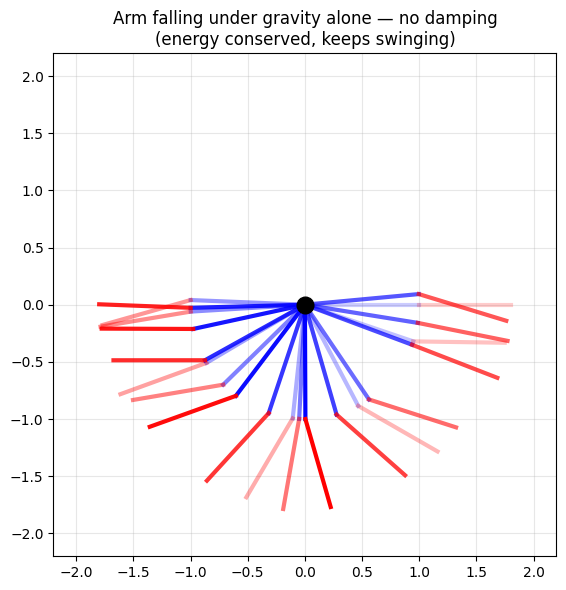

In [116]:
fig, ax = plt.subplots(figsize=(6, 6))

snapshot_indices = np.linspace(0, len(t)-1, 20, dtype=int)

for i, idx in enumerate(snapshot_indices):
    ex, ey, fx, fy = get_arm_points(theta1_hist[idx], theta2_hist[idx])
    alpha = 0.2 + 0.8 * (i / (len(snapshot_indices)-1))
    ax.plot([0, ex], [0, ey], 'b-', linewidth=3, alpha=alpha)
    ax.plot([ex, fx], [ey, fy], 'r-', linewidth=3, alpha=alpha)

ax.plot(0, 0, 'ko', markersize=12)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title('Arm falling under gravity alone — no damping\n(energy conserved, keeps swinging)',
             fontsize=12)
plt.tight_layout()
plt.show()



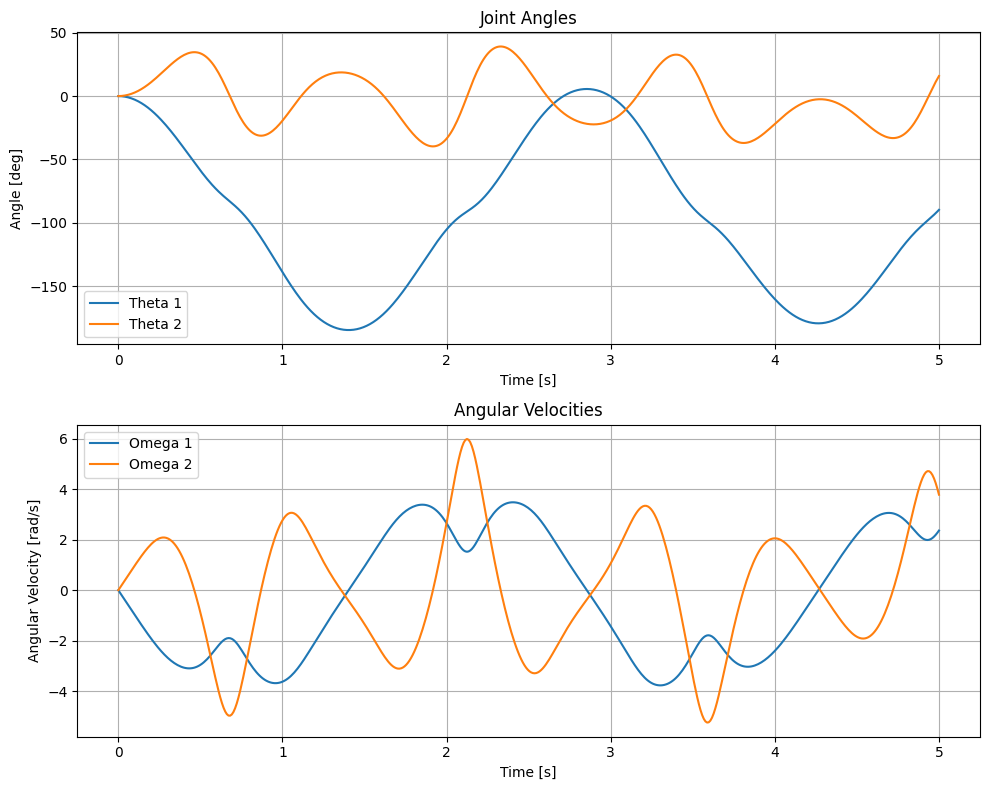

In [117]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Joint angles
ax[0].plot(t, np.degrees(theta1_hist), label='Theta 1')
ax[0].plot(t, np.degrees(theta2_hist), label='Theta 2')

ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Angle [deg]')
ax[0].set_title('Joint Angles')
ax[0].legend()
ax[0].grid(True)

# Angular velocities
ax[1].plot(t, omega1_hist, label='Omega 1')
ax[1].plot(t, omega2_hist, label='Omega 2')

ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Angular Velocity [rad/s]')
ax[1].set_title('Angular Velocities')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

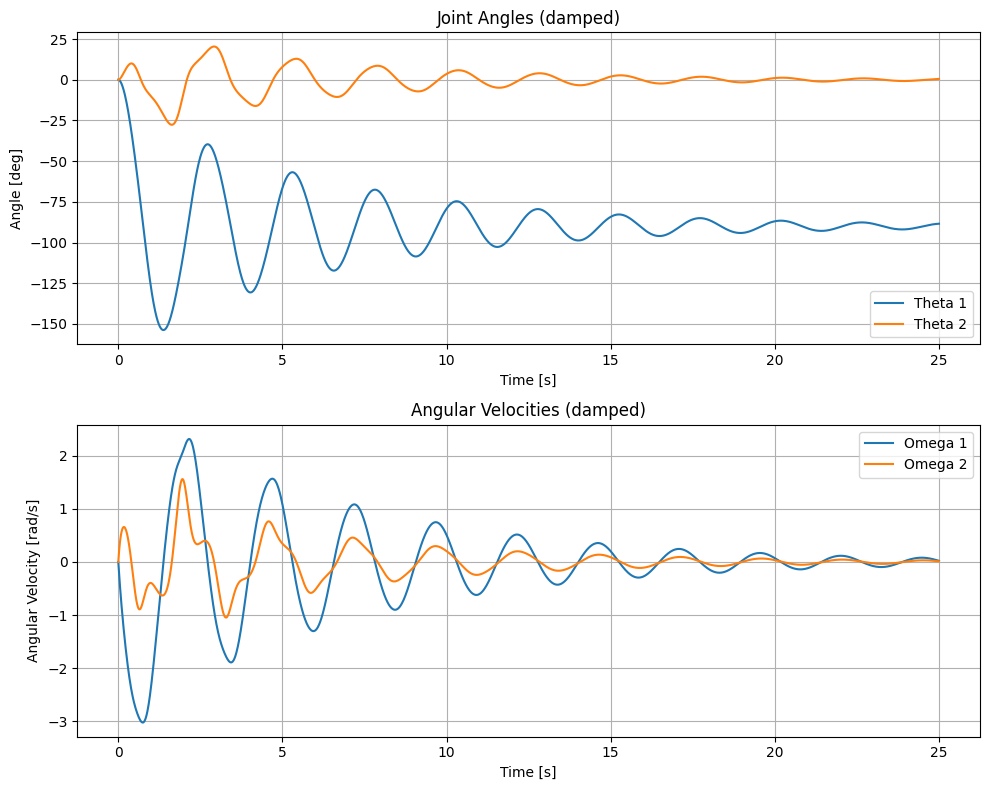

End: theta1=-88.44°, theta2=0.57°
End: omega1=0.02106, omega2=0.01126


In [118]:
# simulation with damping
def arm_dynamics_damped(t, state, torque, damping):
    theta1, theta2, omega1, omega2 = state
    M = mass_matrix(theta2)
    C = coriolis_forces(theta2, omega1, omega2)
    G = gravity_forces(theta1, theta2)
    friction = damping * np.array([omega1, omega2])
    theta_ddot = np.linalg.inv(M) @ (torque - C - G - friction)
    return [omega1, omega2, theta_ddot[0], theta_ddot[1]]

# Same starting point as before: horizontal, at rest
initial_state = [np.radians(0), np.radians(0), 0.0, 0.0]
t_span = (0, 25)
t_eval_d = np.linspace(0, 25, 2000)

sol_damped = solve_ivp(
    arm_dynamics_damped, t_span, initial_state,
    t_eval=t_eval_d, method='RK45', args=(np.array([0.,0.]), 1.2),
    rtol=1e-10, atol=1e-12
)

theta1_d = sol_damped.y[0]
theta2_d = sol_damped.y[1]
omega1_d = sol_damped.y[2]
omega2_d = sol_damped.y[3]
t_2 = sol_damped.t

fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(sol_damped.t, np.degrees(theta1_d), label='Theta 1')
ax[0].plot(sol_damped.t, np.degrees(theta2_d), label='Theta 2')
ax[0].set_xlabel('Time [s]'); ax[0].set_ylabel('Angle [deg]')
ax[0].set_title('Joint Angles (damped)'); ax[0].legend(); ax[0].grid(True)

ax[1].plot(sol_damped.t, omega1_d, label='Omega 1')
ax[1].plot(sol_damped.t, omega2_d, label='Omega 2')
ax[1].set_xlabel('Time [s]'); ax[1].set_ylabel('Angular Velocity [rad/s]')
ax[1].set_title('Angular Velocities (damped)'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout()
plt.show()
print(f"End: theta1={np.degrees(theta1_d[-1]):.2f}°, theta2={np.degrees(theta2_d[-1]):.2f}°")
print(f"End: omega1={omega1_d[-1]:.5f}, omega2={omega2_d[-1]:.5f}")

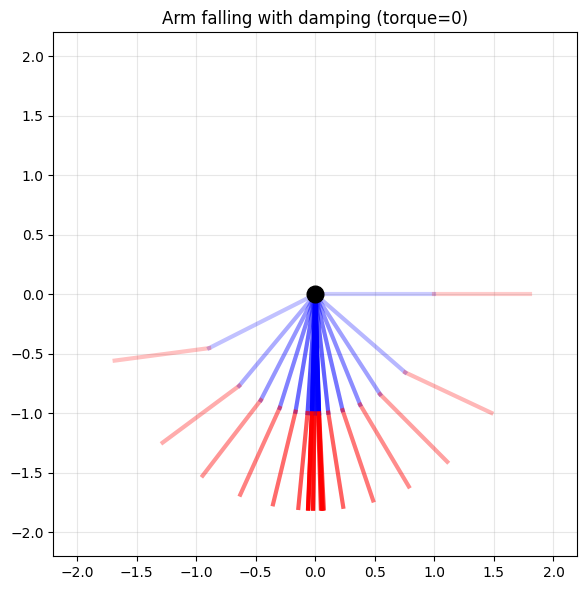

In [125]:
# Under damping
fig, ax = plt.subplots(figsize=(6, 6))
# Plot several snapshots in time to see the fall
snapshot_indices_2 = np.linspace(0, len(t_2)-1, 20, dtype=int)
#idx is a real index value
for i, idx in enumerate(snapshot_indices_2):
    ex, ey, fx, fy = get_arm_points(theta1_d[idx], theta2_d[idx])
    # Fade older positions, highlight the latest one
    alpha = 0.2 + 0.8 * (i / (len(snapshot_indices_2)-1))
    ax.plot([0, ex], [0, ey], 'b-', linewidth=3, alpha=alpha)
    ax.plot([ex, fx], [ey, fy], 'r-', linewidth=3, alpha=alpha)

ax.plot(0, 0, 'ko', markersize=12)
ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-2.2, 2.2)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title('Arm falling with damping (torque=0)')
plt.tight_layout()
plt.show()




In [121]:
print(f"Is t_2 same as sol_damped.t? {np.array_equal(t_2, sol_damped.t)}")
print(f"Length of theta1_d: {len(theta1_d)}, Length of t_2: {len(t_2)}")

Is t_2 same as sol_damped.t? True
Length of theta1_d: 2000, Length of t_2: 2000


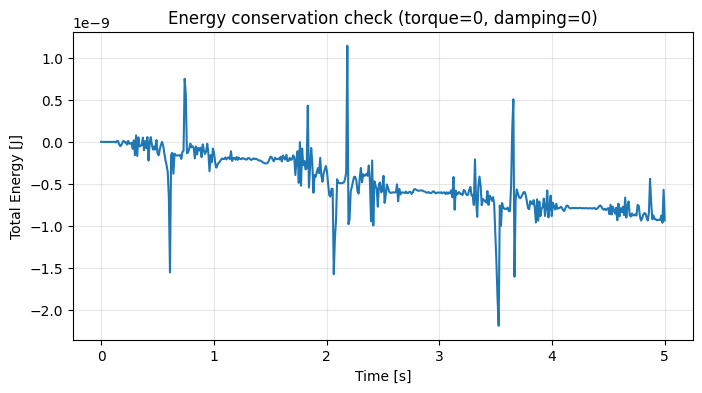

Energy at t=0:  0.000000
Energy at t=end: -0.000000
Drift: 9.35e-10


In [122]:
#Conservation of Energy: when damping = 0,
# torque = 0, total energy(potential + kinetic) is steady

def total_energy(theta1, theta2, omega1, omega2):
    """Kinetic + potential energy of the 2-link arm."""
    M = mass_matrix(theta2)
    omega_vec = np.array([omega1, omega2])

    # Kinetic energy: T = 0.5 * omega^T @ M @ omega
    T = 0.5 * omega_vec @ M @ omega_vec

    #Potential energy: V = m1*g*y1 + m2*g*y2
    y1 = L1 * np.sin(theta1)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    V = m1*g*y1 + m2*g*y2

    return T + V

#Compute energy at every recorded time point (using the undamp sim)
energy_history = [total_energy(theta1_hist[i], theta2_hist[i],
                               omega1_hist[i], omega2_hist[i])
                               for i in range(len(sol.t))]

plt.figure(figsize=(8,4))
plt.plot(sol.t, energy_history)
plt.xlabel('Time [s]')
plt.ylabel('Total Energy [J]')
plt.title('Energy conservation check (torque=0, damping=0)')
plt.grid(alpha=0.3)
plt.show()
print(f"Energy at t=0:  {energy_history[0]:.6f}")
print(f"Energy at t=end: {energy_history[-1]:.6f}")
print(f"Drift: {abs(energy_history[-1]-energy_history[0]):.2e}")